    SGD-MDS may not have converged: stress changed by 3.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
2025-11-03 18:29:24,025 - INFO - Epoch 0/100 - Recon Loss: 0.5682958 - Geo Loss: 0.0207961
2025-11-03 18:29:25,143 - INFO - Epoch 50/100 - Recon Loss: 0.2895793 - Geo Loss: 0.0000877


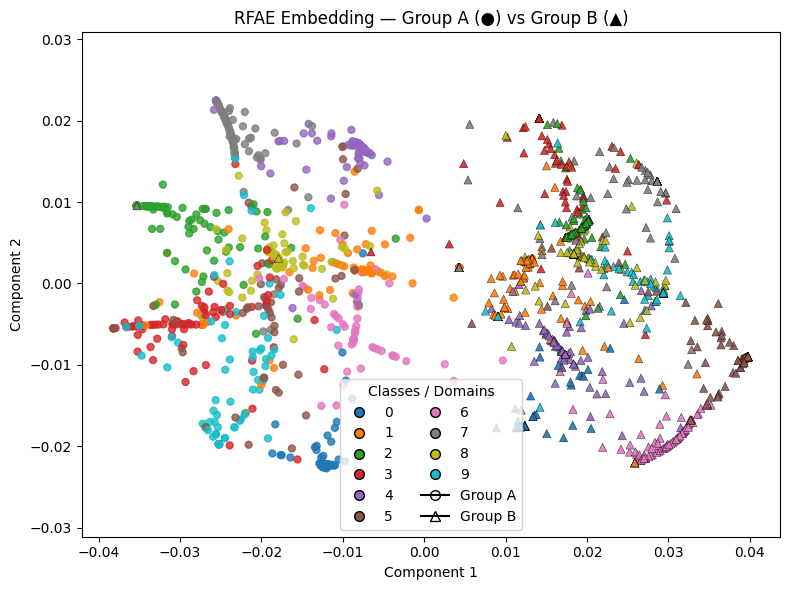

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from rfae import RFAE

# ---------------------------------------------------------
# 1️⃣ Load dataset and create complementary domains
# ---------------------------------------------------------
data = load_digits()
X = data.data.astype(float)
y = data.target

n_samples, n_features = X.shape
rng = np.random.default_rng(seed=42)

# Split samples into two groups (domains)
idx = np.arange(n_samples)
rng.shuffle(idx)
group_A = idx[: n_samples // 2]
group_B = idx[n_samples // 2 :]

# Split features into two disjoint halves
features_A = np.arange(n_features // 2)
features_B = np.arange(n_features // 2, n_features)

# Create complementary missingness
X[group_A[:, None], features_A] = np.nan  # A misses first half
X[group_B[:, None], features_B] = np.nan  # B misses second half

# Domain vector
domains = np.zeros(n_samples, dtype=int)
domains[group_B] = 1  # 0 = A, 1 = B

# ---------------------------------------------------------
# 2️⃣ Fit RFAE on combined data
# ---------------------------------------------------------
model = RFAE(random_state=42, device="mps", epochs=100, lam=0.001, embedder_params={'prox_method': 'rfgap'})
embeddings = model.fit_transform(X, y)

# ---------------------------------------------------------
# 3️⃣ Visualize embeddings (color = label, marker = domain)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Group A (circles)
plt.scatter(
    embeddings[domains == 0, 0],
    embeddings[domains == 0, 1],
    c=y[domains == 0],
    cmap="tab10",
    s=25, alpha=0.8,
    marker="o",
    label="Group A"
)

# Group B (triangles)
plt.scatter(
    embeddings[domains == 1, 0],
    embeddings[domains == 1, 1],
    c=y[domains == 1],
    cmap="tab10",
    s=35, alpha=0.9,
    marker="^",
    edgecolors="k",
    linewidths=0.3,
    label="Group B"
)

plt.title("RFAE Embedding — Group A (●) vs Group B (▲)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.axis("equal")

# Legend: color = class, shape = domain
classes = np.unique(y)
cmap = plt.get_cmap("tab10")
class_handles = [
    plt.Line2D([0], [0],
               marker="o",
               color="none",
               markerfacecolor=cmap(i % 10),
               markersize=7,
               label=str(cls))
    for i, cls in enumerate(classes)
]

domain_handles = [
    plt.Line2D([0], [0],
               marker="o",
               color="k",
               markerfacecolor="none",
               markersize=7,
               label="Group A"),
    plt.Line2D([0], [0],
               marker="^",
               color="k",
               markerfacecolor="none",
               markersize=7,
               label="Group B")
]

plt.legend(handles=class_handles + domain_handles,
           title="Classes / Domains",
           loc="best",
           frameon=True,
           ncol=2)

plt.tight_layout()
plt.show()